Imports

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy import special as sp
import scipy.optimize

filename = "/Users/summer/Downloads/Dineutron/nn_dineutron_spectrum.h5"
L = 48

by_Psq = {} 

with h5py.File(filename, "r") as f:
    mN = f["mN/E0"][()]
    for gname, g in f.items(): #loop through every top-lever group
        if gname == "mN":
            continue  #skip mass group
        q1 = g["Psq_N1"][()][0] #read each momentum label Psq_N1 =  nx^2 + ny^2 + nz^2
        q2 = g["Psq_N2"][()][0]
        by_Psq.setdefault(q1, []).append(g["E_N1"][()]) #put the entire E_N1 array into the dictionary list associated with N1's momentum label Psq_N1
        by_Psq.setdefault(q2, []).append(g["E_N2"][()])

#numpy array of JUST the keys of the by_Psq dictionary
Psq = np.array(sorted(by_Psq)) 
#numpy array of the physical momentum squared corresponding to each Psq value
p2 = (2*np.pi/L)**2 * Psq 
#2D numpy array where each row corresponds to one Psq value (key of dictionary)
#Column 0: average of all element 0 central energies 
# Columnn 1: average of all element 1 bootstrap (repeat until 5000th boostrap)
E = np.array([np.mean(by_Psq[q], axis=0) for q in Psq]) 

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

rng = np.random.default_rng(1234)

filename = "/Users/summer/Downloads/Dineutron/nn_dineutron_spectrum.h5"
L = 48.0
 
punit = 2*np.pi/L
punit2 = punit**2


def boot_err(x):
    return np.std(x[1:], ddof=1) #assumes x[0] is the central value, and x[1:] are the bootstrap samples


def get_dE(g):
    for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
        if key in g:
            return np.array(g[key])
    raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


def get_irrep(name):
    return name.split("_Psq")[0]


def get_Psq_total(name):
    m = re.search(r"Psq(\d+)", name)
    if m is None:
        raise ValueError(f"Could not read total Psq from {name}")
    return int(m.group(1))


def get_level(name):
    m = re.search(r"level(\d+)", name)
    return int(m.group(1)) if m is not None else 0


def dvec_from_d2(d2):
    nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
    best = None
    for nx in range(nmax + 1):
        for ny in range(nmax + 1):
            for nz in range(nmax + 1):
                v = np.array([nx, ny, nz], dtype=int)
                if int(np.dot(v, v)) == int(d2):
                    cand = tuple(sorted(v))
                    if best is None or cand < best:
                        best = cand
    if best is None:
        raise ValueError(f"No integer momentum representative found for Psq={d2}")
    return np.array(best, dtype=int)


raw_levels = []

with h5py.File(filename, "r") as f:
    mN = np.array(f["mN/E0"])
    m = float(mN[0]) #central mass

    for name, g in f.items(): #loop through every top-level group
        if name == "mN":
            continue #skip mN

        irrep = get_irrep(name)
        Psq_tot = get_Psq_total(name)
        print(Psq_tot)
        level_index = get_level(name)

        N1 = int(np.array(g["Psq_N1"])[0])
        N2 = int(np.array(g["Psq_N2"])[0])
       # print(N1, N2)
        dE = get_dE(g)

        #Because mN contains 5001 values, E1 and E2 also contains 5001 values 
        E1 = np.sqrt(mN**2 + punit2*N1) # E^2 = m^2 + p^2, where p^2 = (2*pi/L)^2 * N1
        E2 = np.sqrt(mN**2 + punit2*N2)
        E_NN = dE + E1 + E2 #total interacting energy in og lattice frame 

        E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot) #convert to center of mass energy 
        kstar2 = E_cm**2/4 - mN**2 #calculate the square of the relative momentum
        q2 = kstar2/punit2 #makes momentum dimensionless by dividing by (2*pi/L)^2

        #save for one level
        raw_levels.append({
            "name": name,
            "irrep": irrep,
            "Psq_tot": Psq_tot,
            "level_index": level_index,
            "pair": tuple(sorted((N1, N2))),
            "Ecm_boot": E_cm,
            "q2_boot": q2
        })

raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))

1
1
2
3
4
4
0
0


Plot E_cm vs q^2

Text(0, 0.5, 'E_cm')

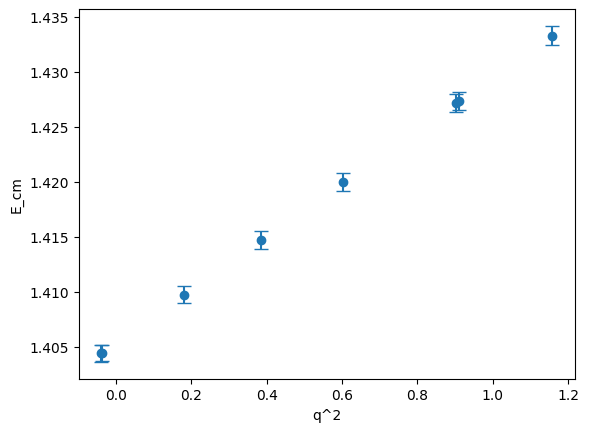

In [3]:
q_squared = []
energy_values = []
energy_errors = []

for level in raw_levels:
    q_squared.append(level["q2_boot"][0])

    central_Ecm = level["Ecm_boot"][0]
    energy_values.append(central_Ecm)

    error_Ecm = boot_err((level["Ecm_boot"]))
    energy_errors.append(error_Ecm)

plt.errorbar(q_squared, energy_values, yerr = energy_errors, fmt='o', capsize=5)
plt.xlabel("q^2")
plt.ylabel("E_cm")

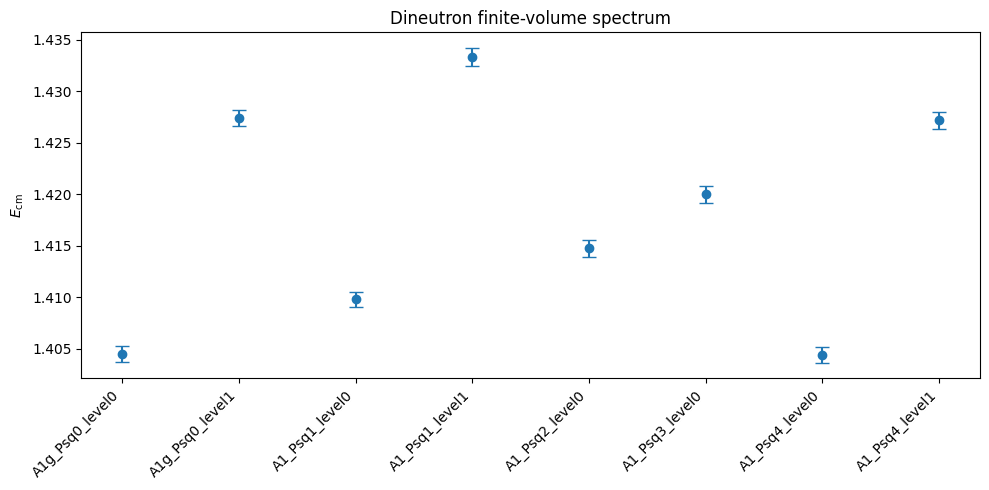

In [4]:
labels = [level["name"] for level in raw_levels]


x = np.arange(8)

plt.figure(figsize=(10, 5))

plt.errorbar(labels, energy_values, yerr = energy_errors, fmt='o', capsize=5)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel(r"$E_{\rm cm}$")
plt.title("Dineutron finite-volume spectrum")
plt.tight_layout()
plt.show()

F Function

In [5]:
'''
Finite-volume function
'''

# Let us work with ideentical particles throughout
xi = 0.5 # symmetry factor
twoPi = 2 * np.pi
m_sq = m*m

# sqrt with branch cut aligned on positive real axis
#def mySqrt(z):
   #return 1j * np.sqrt( -z )
def mySqrt(z):
    z = complex(z)
    return 1j * np.sqrt(-z)

# CM momentum
def q_cm(s):
    return 0.5 * mySqrt( s - 4.0 * m**2 )

# Phase space factor
def phase_space(s):
    return xi * q_cm(s) / ( 8.0 * np.pi * np.sqrt(s) )

# inner product for two list (native)
def dot(A, B):
   return np.dot(A,B) #inner1d(A,B) #np.sum( A * B, axis=1)

# Function to generate 3-tuple "n = (nx,ny,nz)" list
# subject to the constraint nx^2 + ny^2 + nz^2 <= nShell^2,
# where "nShell" indicates the number of shells
def generateIntList( nShell ):
    intList = []
    rawList = np.array(np.arange(-nShell,nShell+1))
    for i in itertools.product(rawList,rawList,rawList):
        tmpList = np.array(i)
        if ( np.dot(tmpList,tmpList) <= nShell*nShell ):
            intList.append(tmpList)

    return np.asarray(intList)

# returns the unit vector of a vector "A"
def unit_vector( A ):
    if( all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime


# cutoff function (alpha input is dimensionless)
def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )

#
# KSS Zeta function for ell = m_ell = 0, given "qcm_sq", total momentum "nP"
# This function is in units of L / 2pi, e.g. m1 -> m1 * L / (2 * pi).
#

# Finite volume function F, given Ecm (units of mass), nP, alpha (dimensionless), and L (units of mass)
# MUST call generateIntList first and use global intList from its output
#
# Note: We chose to have Ecm as input rather than E for convenience in plotting/ pole finding. Coding it the other way works too,
# we are just saving ourselves a couple transformations which are not needed for our purposes.
#
def F_function(Ecm, nP, alpha, L):
    P = twoPi * nP / L
    P_sq = np.dot(P, P)

    E = np.sqrt(Ecm**2 + P_sq)
    s = Ecm**2

    eps = 1e-16

    qcm_value = q_cm(s + 1j * eps)
    qcm_sq = qcm_value**2
    rho = phase_space(s + 1j * eps)

    beta = P / E

    # Each row of k is one allowed 3-momentum
    k = (twoPi / L) * intList

    # Squared magnitude of each momentum vector
    k_sq = np.sum(k**2, axis=1)

    # Energy associated with each momentum vector
    omega = np.sqrt(m*m + k_sq)

    omega_cm, k_cm = lorentzBoost(omega, k, beta)

    # Squared magnitude of each boosted momentum
    k_cm_sq = np.sum(k_cm**2, axis=1)

    cutoff_values = cutoff(
        qcm_sq,
        k_cm_sq,
        alpha,
        L
    )

    tmp = cutoff_values * omega_cm / omega
    tmp = tmp / (qcm_sq - k_cm_sq)

    sum0 = (
        
        xi / (2.0 * Ecm * L**3)
    ) * np.sum(tmp)

    alpha_dim = (L / twoPi)**2 * alpha

    z = np.sqrt(alpha_dim) * qcm_value

    integral = (
        xi / (4.0 * np.pi**2 * Ecm)
    ) * (
        np.sqrt(0.25 * np.pi / alpha_dim)
        * np.exp(alpha_dim * qcm_sq)
        - 0.5
        * np.pi
        * qcm_value
        * sp.erfi(z)
    )

    return 1j * rho + sum0.real + integral



In [6]:
#calculate q2, F, F_pv for each data point
m = float(mN[0])
m_sq = m**2

nShell = 20
intList = generateIntList(nShell)

alpha = 0.125
L = 48
print("m =", m)
print("m_sq =", m_sq)
print("nShell =", nShell)
print("number of momentum vectors =", len(intList))

q2_values_actual_data = []
F_values_actual_data = []
F_pv_values_actual_data = []

eps = 1e-16

for level in raw_levels:
    E_cm = float(level["Ecm_boot"][0])
    nP = dvec_from_d2(level["Psq_tot"])
    print(m, nP, E_cm)
    F_value = F_function(E_cm, nP, alpha, L)
    F_values_actual_data.append(F_value)

    #F_pv
    s = E_cm **2 
    rho_value = phase_space(s + 1j * eps)

    F_pv_value = (F_value - 1j * rho_value).real
    F_pv_values_actual_data.append(F_pv_value)

    #q2
    q2_values_actual_data.append(float(level["q2_boot"][0]))
    

m = 0.7026827020795523
m_sq = 0.4937629798018209
nShell = 20
number of momentum vectors = 33401
0.7026827020795523 [0 0 0] 1.404480193149725
0.7026827020795523 [0 0 0] 1.427387430256371
0.7026827020795523 [0 0 1] 1.4097814949159677
0.7026827020795523 [0 0 1] 1.4333221966427518
0.7026827020795523 [0 1 1] 1.4147421255240087
0.7026827020795523 [1 1 1] 1.4199751076807943
0.7026827020795523 [0 0 2] 1.4044221450218684
0.7026827020795523 [0 0 2] 1.4271811314910883


In [7]:
def M_function_using_F(F):
    return -1.0 / F

Plot M vs q^2 (actual data)

In [8]:
M_real_values = []
M_imag_values = []

for F_value in F_values_actual_data:
    M_value = M_function_using_F(F_value)
    M_real_values.append(M_value.real)
    M_imag_values.append(M_value.imag)

Text(0.5, 1.0, 'M vs q^2 Imaginary part')

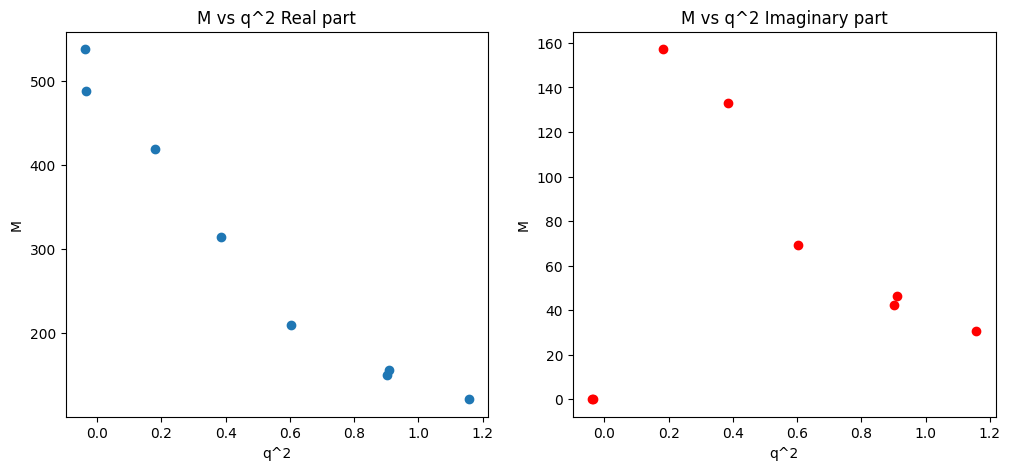

In [9]:
plt.figure(figsize=(12, 5))
m_q2_real = plt.gcf().add_subplot(121)
m_q2_imag = plt.gcf().add_subplot(122)

m_q2_real.scatter(q2_values_actual_data, M_real_values, label="Real part of M")
m_q2_real.set_xlabel("q^2")
m_q2_real.set_ylabel("M")
m_q2_real.set_title("M vs q^2 Real part")

m_q2_imag.scatter(q2_values_actual_data , M_imag_values, label="Imaginary part of M", color = 'red')
m_q2_imag.set_xlabel("q^2")
m_q2_imag.set_ylabel("M")
m_q2_imag.set_title("M vs q^2 Imaginary part")

Plot q^* cot delta vs q^2 (actual data)

In [10]:
q_cot_delta_values = []

for i in range(len(raw_levels)):

    #get level
    level = raw_levels[i]

    #get F_pv 
    F_pv_value = F_pv_values_actual_data[i]

    #CM 
    E_cm = float(level["Ecm_boot"][0])

    #q* cot(delta = -(8* pi * E_cm / xi)(F_pv)
    q_cot_delta = -(8.0 * np.pi * E_cm / xi) * F_pv_value

    q_cot_delta_values.append(q_cot_delta.real)

Text(0, 0.5, 'qcotdelta')

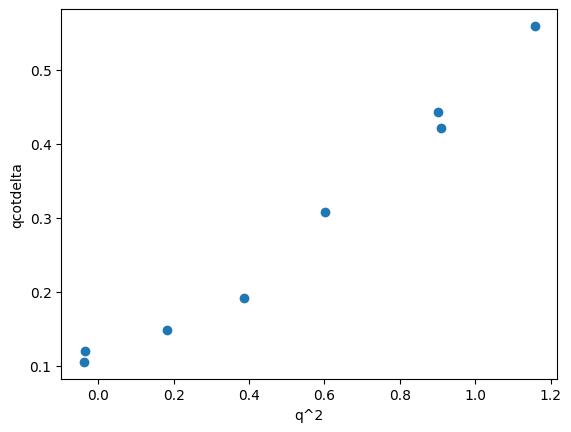

In [11]:
plt.scatter(q2_values_actual_data, q_cot_delta_values)
plt.xlabel("q^2")
plt.ylabel("qcotdelta")


Plot F vs E^* / m vs (synthetic)

In [12]:
m = float(mN[0])
L = 48
e_cm_inputs = np.linspace(2.0001 *m, 10.2 * m, 8000)
shell = 20
alpha = 0.125
intList = generateIntList(shell)
P = np.array([0, 0, 0])

linspace_F_real_values = []
linspace_F_imag_values = []

linspace_M_real_values = []
linspace_M_imag_values= []

for Ecm in e_cm_inputs:
     # Calculate the full complex F value once
    F_value = F_function(Ecm, P, alpha, L)

    # Store its real and imaginary parts
    linspace_F_real_values.append(F_value.real)
    linspace_F_imag_values.append(F_value.imag)

    # Calculate M using the full complex F value
    M_value = M_function_using_F(F_value)

    # Store its real and imaginary parts
    linspace_M_real_values.append(M_value.real)
    linspace_M_imag_values.append(M_value.imag)

(1.9, 4.0)

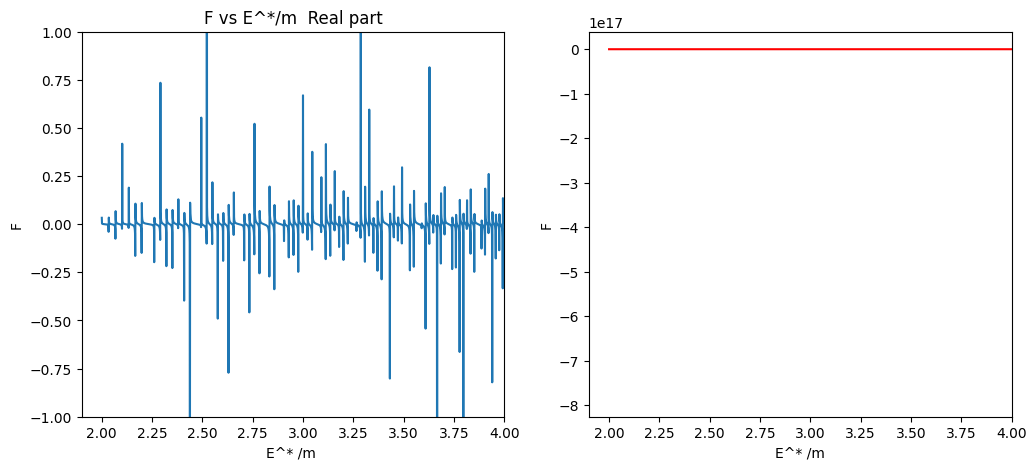

In [13]:
plt.figure(figsize=(12, 5))
f_e_real = plt.gcf().add_subplot(121)
f_e_imag = plt.gcf().add_subplot(122)

f_e_real.plot(e_cm_inputs / m, linspace_F_real_values, label="Real part of F")
f_e_real.set_xlabel("E^* /m ")
f_e_real.set_ylabel("F")
f_e_real.set_title("F vs E^*/m  Real part")
f_e_real.set_xlim(1.9, 4.0)
f_e_real.set_ylim(-1, 1)

f_e_imag.plot(e_cm_inputs / m , linspace_F_imag_values, label="Imaginary part of F", color = 'red')
f_e_imag.set_xlabel("E^* /m")
f_e_imag.set_ylabel("F")
#ax6.set_title("F vs E^*/m Imaginary part")
f_e_imag.set_xlim(1.9, 4.0)

45


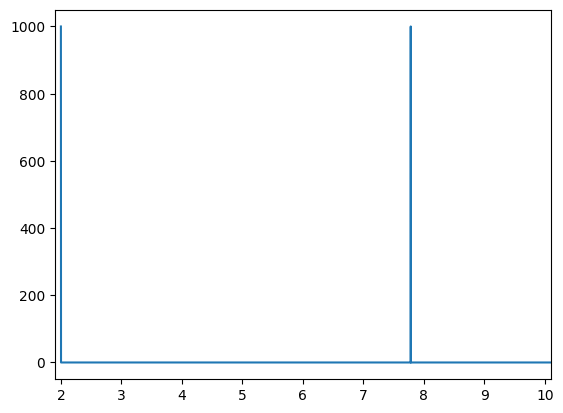

In [14]:
#Ryan's OG
import numpy as np
import matplotlib.pyplot as plt

M = 0.0696
L = 24

d = np.array([0, 0, 0])
punit = 2 * np.pi / L
Pvec = punit * d
P2 = np.dot(Pvec, Pvec)

E_min = 2 * M
E_max = 10 * M

levels = []

E_grid = np.linspace(2 * M, 10.2 * M, 8000)
F = np.zeros_like(E_grid)

for i in range(-5, 6):
    for j in range(-5, 6):
        for k in range(-5, 6):

            n1 = np.array([i, j, k])
            n2 = d - n1

            p1 = punit * n1
            p2 = punit * n2

            E_lab = (np.sqrt(np.dot(p1, p1) + M**2) +
                     np.sqrt(np.dot(p2, p2) + M**2))
           
            E_star = np.sqrt(E_lab**2 - P2)
            levels.append(E_star)

levels = np.unique(np.round(levels, 12))

for E_star in levels:
    idx = np.argmin(np.abs(E_grid - E_star))
    F[idx] = 1000 #np.inf

print(len(levels))

plt.plot(E_grid / M, F)
plt.xlim(1.9, 10.1)
plt.show()


727


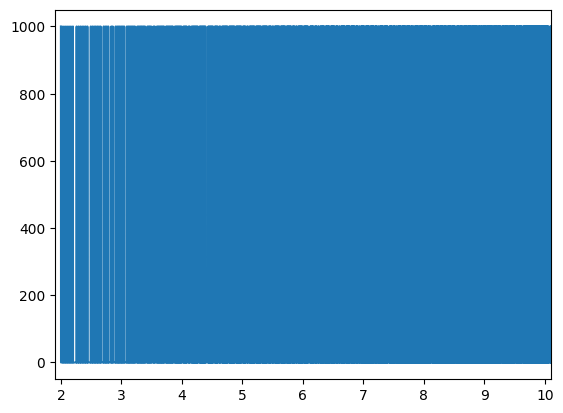

In [15]:
#overall with updated M and L

M = m
L = 48

d = np.array([0, 0, 0])
punit = 2 * np.pi / L
Pvec = punit * d
P2 = np.dot(Pvec, Pvec)

E_min = 2 * M
E_max = 10 * M

levels = []

E_grid = np.linspace(2 * M, 10.2 * M, 8000)
F = np.zeros_like(E_grid)

maxshell = 20
for i in range(-maxshell, maxshell+1):
    for j in range(-maxshell, maxshell +1):
        for k in range(-maxshell, maxshell +1 ):

            n1 = np.array([i, j, k])
            n2 = d - n1

            p1 = punit * n1
            p2 = punit * n2

            E_lab = (np.sqrt(np.dot(p1, p1) + M**2) +
                     np.sqrt(np.dot(p2, p2) + M**2))
           
            E_star = np.sqrt(E_lab**2 - P2)
            levels.append(E_star)

levels = np.unique(np.round(levels, 12))

for E_star in levels:
    idx = np.argmin(np.abs(E_grid - E_star))
    F[idx] = 1000 #np.inf

print(len(levels))

plt.plot(E_grid / M, F)
plt.xlim(1.9, 10.1)
plt.show()


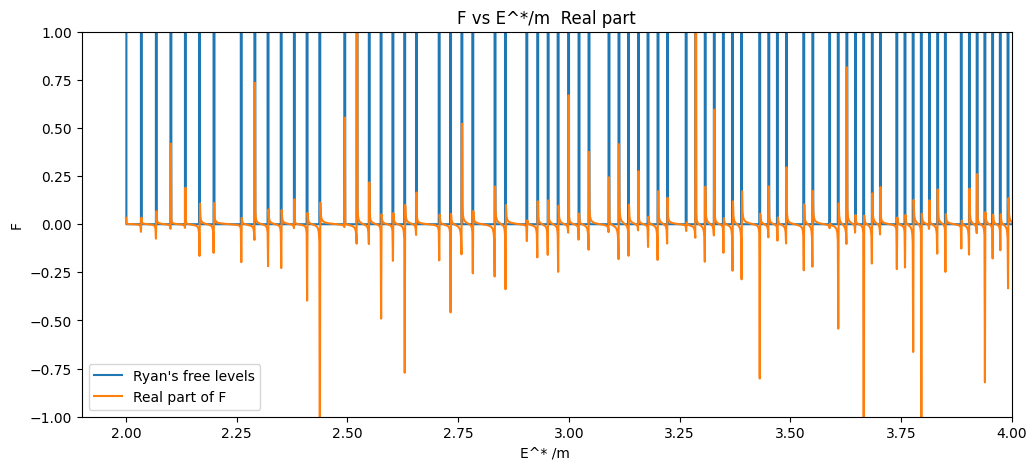

In [16]:
plt.figure(figsize=(12, 5))
overlayed = plt.gcf().add_subplot()

overlayed.plot(E_grid / M, F, label = "Ryan's free levels")
overlayed.plot(e_cm_inputs / m, linspace_F_real_values, label="Real part of F")


overlayed.set_xlabel("E^* /m ")
overlayed.set_ylabel("F")
overlayed.set_title("F vs E^*/m  Real part")
overlayed.set_xlim(1.9, 4.0)
overlayed.set_ylim(-1, 1)
overlayed.legend()

(1.9, 4.0)

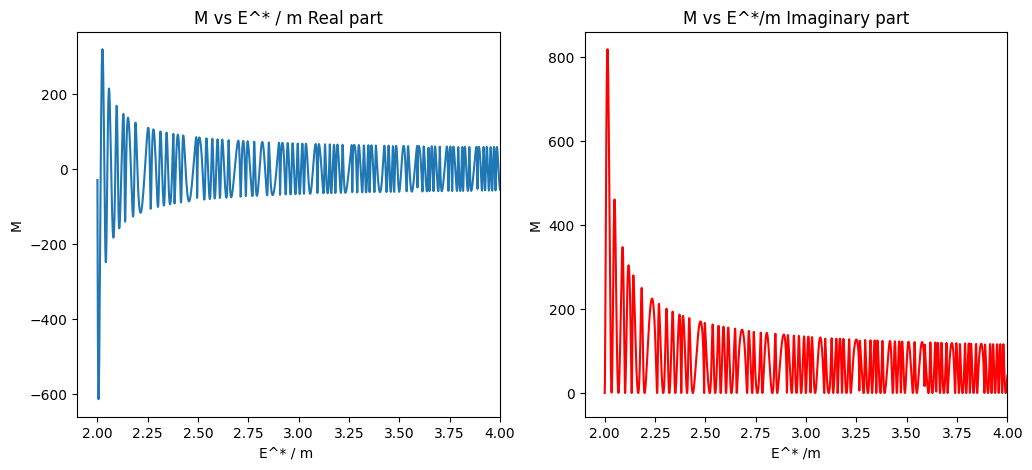

In [17]:
plt.figure(figsize=(12, 5))
m_e_real = plt.gcf().add_subplot(121)
m_e_imag = plt.gcf().add_subplot(122)

m_e_real.plot(e_cm_inputs / m, linspace_M_real_values, label="Real part of M")
m_e_real.set_xlabel("E^* / m ")
m_e_real.set_ylabel("M")
m_e_real.set_title("M vs E^* / m Real part")
m_e_real.set_xlim(1.9, 4.0)


m_e_imag.plot(e_cm_inputs / m , linspace_M_imag_values, label="Imaginary part of M", color = 'red')
m_e_imag.set_xlabel("E^* /m")
m_e_imag.set_ylabel("M")
m_e_imag.set_title("M vs E^*/m Imaginary part")
m_e_imag.set_xlim(1.9, 4.0)


Fitting a & r

In [18]:
right_side_actual_data = []
qcm_actual_data = []

for i in range(len(raw_levels)):

    E_cm = float(raw_levels[i]["Ecm_boot"][0])
    s = E_cm **2 
    q = q_cm(s + eps * 1j)

    qcm_actual_data.append(q)

    F_value = F_values_actual_data[i]
    

    right_side = -(8.0 * np.pi * E_cm * F_value / xi) + 1j * q

    right_side_actual_data.append(right_side)

qcm_actual_data = np.array(qcm_actual_data, dtype = complex)
right_side_actual_data = np.array(right_side_actual_data, dtype=complex)

In [19]:
def left_side(q_cm, a , r):
    return ((-1/a) + (0.5 * r * (q_cm)**2))

In [20]:
a_values = np.arange(-20,0,0.01)
r_values = np.arange(0,50,0.01)

results = [] 

for a in range(len(a_values)):
    possible_a = a_values[a]

    for r in range(len(r_values)):
        possible_r = r_values[r]
        
        total_difference = 0
        for i in range(len(qcm_actual_data)):
            current_qcm = qcm_actual_data[i]

            possible_left = left_side(current_qcm, possible_a, possible_r)

            difference = np.abs(possible_left - right_side_actual_data[i])

            total_difference += difference**2

        results.append((possible_a, possible_r, total_difference))

results.sort(key=lambda result: result[2])


KeyboardInterrupt: 

In [21]:
for i in range(10):
    print(results[i])

(np.float64(-10.069999999998448), np.float64(43.13), np.float64(0.005888289449750811))
(np.float64(-10.059999999998446), np.float64(43.12), np.float64(0.005888295972716171))
(np.float64(-10.059999999998446), np.float64(43.11), np.float64(0.005888297810268202))
(np.float64(-10.069999999998448), np.float64(43.12), np.float64(0.005888308219303111))
(np.float64(-10.069999999998448), np.float64(43.14), np.float64(0.005888322489832317))
(np.float64(-10.059999999998446), np.float64(43.13), np.float64(0.005888345944797934))
(np.float64(-10.059999999998446), np.float64(43.1), np.float64(0.005888351457454043))
(np.float64(-10.07999999999845), np.float64(43.14), np.float64(0.005888352944743183))
(np.float64(-10.049999999998445), np.float64(43.1), np.float64(0.005888357802139327))
(np.float64(-10.07999999999845), np.float64(43.15), np.float64(0.005888369189216554))


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0.5, 0, 'q^*^2')

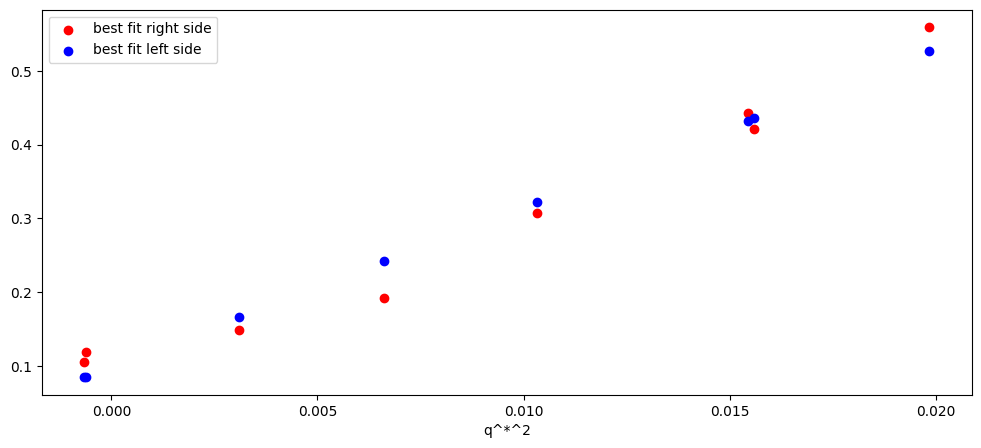

In [22]:
best_a = results[0][0]
best_r = results[0][1]

left_side_actual_data = []

for i in range(len(qcm_actual_data)):
    left_side_actual_data.append(left_side(qcm_actual_data[i], best_a, best_r))

qcm_sq_actual_data = qcm_actual_data**2

plt.figure(figsize=(12,5))

plt.scatter(qcm_sq_actual_data, right_side_actual_data.real, color='red', label="best fit right side")
plt.scatter(qcm_sq_actual_data, np.array(left_side_actual_data), color = 'blue', label = "best fit left side")
plt.legend()
plt.xlabel("q^*^2")




Fit energy spectrum

workflow for fitting energy spectrum

1. select a and r to plug into the quantization condition
2. find which energies satisfy the quantization condition (find when the value of the quantization condition changes signs. and use the point slope to determine exact point)
3. compare the energies (might not necessarily be 8 values) to the 8 data point values (if there is more/less than 8 predicted data points, disregard it)
4. calcuate the chi squared for that a and r (8 things added up together) - (observed - predicted)^2 / (standard error for that point). 
5. repeat for other a and r values to find the best a and r. 

- 2 Psq0
- 2 Psq1
- 1 Psq2
- 1 Psq3
- 2 Psq4

In [73]:
#Actual Data
actual_data = {
    0: [],
    1: [],
    2: [],
    3: [],
    4: []
}

for level in raw_levels:

    Psq = level["Psq_tot"]

    actual_energy = level["Ecm_boot"][0]
    error = boot_err(level["Ecm_boot"])

    actual_data[Psq].append(
        [actual_energy, error]
    )

#Energy Array
Ecm_values = np.array([level["Ecm_boot"][0] for level in raw_levels])

min_ecm = min(Ecm_values) - 0.005
max_ecm = max(Ecm_values) + 0.005

min_max_energies = np.linspace(min_ecm, max_ecm, 5000)


#0, 1, 2, 3, 4
unique_Psq_tot_values = sorted(
    set(level["Psq_tot"] for level in raw_levels)
)

#correct amount of zeros
number_zeros_by_Psq = {
    0: 2,
    1: 2,
    2: 1,
    3: 1,
    4: 2
}

In [74]:
def mySqrt_vectorized(z):
    z = np.asarray(z, dtype=complex)
    return 1j * np.sqrt(-z)

def q_cm_vectorized(s):
    return 0.5 * mySqrt_vectorized(s - 4.0 * m**2)

In [75]:
#Calculate Poles (Non interacting energy)
poles_by_Psq ={}

M =  float(mN[0])
L = 48

d_by_Psq = {
    0: np.array([0, 0, 0]),
    1: np.array([0, 0, 1]),
    2: np.array([0, 1, 1]),
    3: np.array([1, 1, 1]),
    4: np.array([0, 0, 2])
}
punit = 2 * np.pi / L

maxshell = 20
E_min = min_ecm
E_max = max_ecm

for Psq_tot, d in d_by_Psq.items():
    Pvec = punit * d
    P2 = np.dot(Pvec, Pvec)

    poles = []

    for i in range(-maxshell, maxshell+1):
        for j in range(-maxshell, maxshell +1):
            for k in range(-maxshell, maxshell +1 ):

                n1 = np.array([i, j, k])
                n2 = d - n1

                p1 = punit * n1
                p2 = punit * n2

                E_lab = (np.sqrt(np.dot(p1, p1) + M**2) +
                        np.sqrt(np.dot(p2, p2) + M**2))
            
                E_star = np.sqrt(E_lab**2 - P2)
                if E_min <= E_star <= E_max:
                    poles.append(E_star)

    poles_by_Psq[Psq_tot] = np.unique(np.round(poles,12))

for Psq in sorted(poles_by_Psq):
    print(f"\nPsq = {Psq}")
    print(poles_by_Psq[Psq])



Psq = 0
[1.4053654  1.42954218]

Psq = 1
[1.41139666 1.43547353]

Psq = 2
[1.41730256 1.41750534]

Psq = 3
[1.42308947 1.42348685]

Psq = 4
[1.4053654  1.42876324 1.42954218]


In [76]:
#Precompute F values
F_by_Psq = {}

for Psq_tot in unique_Psq_tot_values:
    nP = dvec_from_d2(Psq_tot)

    F_by_Psq[Psq_tot] = np.array([
        F_function(Ecm, nP, alpha, L)
        for Ecm in min_max_energies
    ])

In [77]:
def M_using_a_r(Ecm, a, r):
    s = Ecm**2
    qcm = q_cm_vectorized(s)
    effective_range = (-1/a) + 0.5 * r * (qcm**2)
    return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))
def quantization_values_function(a, r, Psq_tot):
    M_values = M_using_a_r(min_max_energies, a, r)
    F_values = F_by_Psq[Psq_tot]

    return np.real(
        1.0 / M_values + F_values
    )

In [78]:
def find_zeros(
    quantization_values,
    energies,
    poles
):
    zeros = []

    for i in range(len(energies) - 1):
        current_q = quantization_values[i]
        next_q = quantization_values[i + 1]

        current_e = energies[i]
        next_e = energies[i + 1]

        if not (
            np.isfinite(current_q)
            and np.isfinite(next_q)
        ):
            continue

        sign_change = (
            (current_q < 0 and next_q > 0)
            or
            (current_q > 0 and next_q < 0)
        )


        if not sign_change:
            continue


        pole_between = np.any(
            (poles >= current_e)
            & (poles <= next_e)
        )

        if pole_between:
            print("Rejected: noninteracting pole")
            continue

        slope = (
            (next_q - current_q)
            / (next_e - current_e)
        )

        energy_zero = (
            current_e - current_q / slope
        )

        print(f"Accepted zero at E = {energy_zero:.9f}")

        zeros.append(energy_zero)

    return np.array(zeros)


In [79]:
def select_lowest_zeros(zeros, number_expected):
    zeros = np.sort(np.asarray(zeros, dtype=float))

    if len(zeros) < number_expected:
        return None
    
    return zeros[:number_expected]

In [80]:
#Calculate Covariance Matrix
bootstrap_matrix = []

for level in raw_levels:
    bootstrap_samples = level["Ecm_boot"][1:]
    bootstrap_matrix.append(bootstrap_samples)

bootstrap_matrix = np.array(bootstrap_matrix)

covariance = np.cov(bootstrap_matrix)

#Calculate inverse covariance matrix 
inverse_covariance = np.linalg.inv(covariance)

print(bootstrap_matrix.shape)
print(covariance.shape)
print(inverse_covariance.shape)

(8, 5000)
(8, 8)
(8, 8)


In [81]:
def calculate_residuals(zeros, measured_levels, show_matches = True):
    zeros = sorted(list(zeros))
    measured_levels = sorted(measured_levels, key=lambda level: level[0])
    residuals = []

    for actual_energy, error in measured_levels:
        closest_root = zeros[0]
        
        for root in zeros:
            if abs(root - actual_energy) < abs(closest_root - actual_energy):
                closest_root = root

        residual = closest_root - actual_energy
        residuals.append(residual)

        if show_matches:
            print("Measured energy: ", actual_energy)
            print("Predicted root: ", closest_root)
            print("Residual: ", residual)
            print()
        
        zeros.remove(closest_root)
    
    if show_matches:
        print("Unused roots: ", zeros)
        print()

    return residuals


In [82]:
def total_chi_squared(parameters):

    a = parameters[0]
    r = parameters[1]

    all_residuals = []

    for Psq_tot in unique_Psq_tot_values:
        
        measured_levels = actual_data[Psq_tot]

        quantization_values = quantization_values_function(
            a,
            r,
            Psq_tot
        )

        zeros = find_zeros(
            quantization_values,
            min_max_energies,
            poles_by_Psq[Psq_tot]
        )

        number_expected = len(measured_levels)

        selected_zeros = select_lowest_zeros(zeros, number_expected)

        #Too few roots 
        if selected_zeros is None:
            return np.inf
    

        residuals_for_sector = calculate_residuals(selected_zeros, measured_levels)
        all_residuals.extend(residuals_for_sector)
    

    delta = np.array(all_residuals)

    chi_squared = float(delta.T @ inverse_covariance @ delta)

    return chi_squared

In [88]:
valid_trials = [] 

a_arange = np.arange(-10,0,1)
r_arange = np.arange(30,40,1)
for a in a_arange:

    if a == 0:
        continue

    for r in r_arange:

        zeros_by_Psq = {}
        all_residuals = []

        enough_roots = True

        for Psq_tot in unique_Psq_tot_values:

            quantization_values = quantization_values_function(a, r, Psq_tot)

            zeros = find_zeros(quantization_values, min_max_energies, poles_by_Psq[Psq_tot])

            measured_levels = actual_data[Psq_tot]

            number_expected = len(measured_levels)

            selected_zeros = select_lowest_zeros(zeros, number_expected)

            if selected_zeros is None:
                enough_roots = False
                break

            zeros_by_Psq[Psq_tot] = selected_zeros

            
            residual_per_Psq = calculate_residuals(selected_zeros, measured_levels)
            all_residuals.extend(residual_per_Psq)

        if enough_roots:

            if len(all_residuals) != inverse_covariance.shape[0]:
                print("Residual length:", len(all_residuals))
                print("Covariance size:", inverse_covariance.shape)
                raise ValueError("Residual vector length does not match covariance matrix.")

            delta = np.array(all_residuals)
            chi_squared = (delta.T @ inverse_covariance @ delta)

        
            valid_trials.append({
                "a" : a,
                "r" : r,
                "chi_squared": chi_squared,
                "zeros_by_Psq" : zeros_by_Psq
            })


Accepted zero at E = 1.404305343
Rejected: noninteracting pole
Accepted zero at E = 1.426833370
Rejected: noninteracting pole
Measured energy:  1.404480193149725
Predicted root:  1.4043053431644692
Residual:  -0.00017484998525585382

Measured energy:  1.427387430256371
Predicted root:  1.4268333696623325
Residual:  -0.0005540605940383969

Unused roots:  []

Accepted zero at E = 1.409766011
Rejected: noninteracting pole
Accepted zero at E = 1.432475866
Rejected: noninteracting pole
Measured energy:  1.4097814949159677
Predicted root:  1.40976601111502
Residual:  -1.548380094762436e-05

Measured energy:  1.4333221966427518
Predicted root:  1.432475866455611
Residual:  -0.0008463301871408646

Unused roots:  []

Accepted zero at E = 1.414825043
Rejected: noninteracting pole
Accepted zero at E = 1.417408178
Rejected: noninteracting pole
Measured energy:  1.4147421255240087
Predicted root:  1.4148250427486055
Residual:  8.29172245968568e-05

Unused roots:  []

Accepted zero at E = 1.41935480

In [89]:
valid_trials.sort(key=lambda x: x["chi_squared"])

In [91]:
for trial in valid_trials[:10]:
    print()
    print("a =", trial["a"])
    print("r =", trial["r"])
    print("chi squared:", trial["chi_squared"])

    for Psq_tot, zeros in trial["zeros_by_Psq"].items():
        print(
            "Psq",
            Psq_tot,
            "found",
            len(zeros),
            "expected",
            number_zeros_by_Psq[Psq_tot]
        )


a = -10
r = 38
chi squared: 4.216743924800074
Psq 0 found 2 expected 2
Psq 1 found 2 expected 2
Psq 2 found 1 expected 1
Psq 3 found 1 expected 1
Psq 4 found 2 expected 2

a = -10
r = 39
chi squared: 4.267702981798013
Psq 0 found 2 expected 2
Psq 1 found 2 expected 2
Psq 2 found 1 expected 1
Psq 3 found 1 expected 1
Psq 4 found 2 expected 2

a = -10
r = 37
chi squared: 4.270718561942125
Psq 0 found 2 expected 2
Psq 1 found 2 expected 2
Psq 2 found 1 expected 1
Psq 3 found 1 expected 1
Psq 4 found 2 expected 2

a = -10
r = 36
chi squared: 4.439648381707757
Psq 0 found 2 expected 2
Psq 1 found 2 expected 2
Psq 2 found 1 expected 1
Psq 3 found 1 expected 1
Psq 4 found 2 expected 2

a = -9
r = 38
chi squared: 4.544703783719736
Psq 0 found 2 expected 2
Psq 1 found 2 expected 2
Psq 2 found 1 expected 1
Psq 3 found 1 expected 1
Psq 4 found 2 expected 2

a = -9
r = 39
chi squared: 4.58193991138986
Psq 0 found 2 expected 2
Psq 1 found 2 expected 2
Psq 2 found 1 expected 1
Psq 3 found 1 expecte

In [97]:
initial_guess = [-10 , 38]

result = scipy.optimize.minimize(
    total_chi_squared,
    initial_guess,
    method="Nelder-Mead"
)

Accepted zero at E = 1.404282757
Rejected: noninteracting pole
Accepted zero at E = 1.427250232
Rejected: noninteracting pole
Measured energy:  1.404480193149725
Predicted root:  1.4042827574870298
Residual:  -0.0001974356626952556

Measured energy:  1.427387430256371
Predicted root:  1.4272502315588749
Residual:  -0.00013719869749606595

Unused roots:  []

Accepted zero at E = 1.409869225
Rejected: noninteracting pole
Accepted zero at E = 1.432958238
Rejected: noninteracting pole
Measured energy:  1.4097814949159677
Predicted root:  1.4098692252683394
Residual:  8.773035237163995e-05

Measured energy:  1.4333221966427518
Predicted root:  1.432958237674302
Residual:  -0.0003639589684498734

Unused roots:  []

Accepted zero at E = 1.415095841
Rejected: noninteracting pole
Accepted zero at E = 1.417408722
Rejected: noninteracting pole
Measured energy:  1.4147421255240087
Predicted root:  1.4150958408462484
Residual:  0.0003537153222397116

Unused roots:  []

Accepted zero at E = 1.419854

In [98]:
best_a, best_r = result.x
a_fit, r_fit = result.x


print("chi-squared =", result.fun)
print("success =", result.success)
print("message =", result.message)
print("Best fit:")
print("a =", best_a)
print("r =", best_r)
print()

for Psq_tot in unique_Psq_tot_values:

    print("Psq =", Psq_tot)

    quantization_values = quantization_values_function(
        best_a,
        best_r,
        Psq_tot
    )

    zeros = find_zeros(
        quantization_values,
        min_max_energies,
        poles_by_Psq[Psq_tot]
    )

    print("Predicted roots:")
    print(zeros)
    print()

    print("Measured levels:")
    print(actual_data[Psq_tot])
    print("----------------------------")

chi-squared = 3.8286713122170277
success = True
message = Optimization terminated successfully.
Best fit:
a = -13.322773791561822
r = 37.264583027114895

Psq = 0
Accepted zero at E = 1.404046692
Rejected: noninteracting pole
Accepted zero at E = 1.427058843
Rejected: noninteracting pole
Predicted roots:
[1.40404669 1.42705884]

Measured levels:
[[np.float64(1.404480193149725), np.float64(0.0007506551218981072)], [np.float64(1.427387430256371), np.float64(0.0007935596115245533)]]
----------------------------
Psq = 1
Accepted zero at E = 1.409633117
Rejected: noninteracting pole
Accepted zero at E = 1.432778227
Rejected: noninteracting pole
Predicted roots:
[1.40963312 1.43277823]

Measured levels:
[[np.float64(1.4097814949159677), np.float64(0.0007684675439241838)], [np.float64(1.4333221966427518), np.float64(0.0008761569775460531)]]
----------------------------
Psq = 2
Accepted zero at E = 1.414816835
Rejected: noninteracting pole
Accepted zero at E = 1.417408273
Rejected: noninteracti

In [99]:
for Psq_tot in unique_Psq_tot_values:

    print("Psq =", Psq_tot)

    quantization_values = quantization_values_function(
        best_a,
        best_r,
        Psq_tot
    )

    # Every mathematical zero
    all_zeros = find_zeros(
        quantization_values,
        min_max_energies,
        poles_by_Psq[Psq_tot]
    )

    measured_levels = actual_data[Psq_tot]
    number_expected = len(measured_levels)

    # Only the roots included in chi-squared
    selected_zeros = select_lowest_zeros(
        all_zeros,
        number_expected
    )

    print("All zeros found:")
    print(all_zeros)

    print("Zeros used in fit:")
    print(selected_zeros)

    print("Measured levels:")
    print(measured_levels)

    print("----------------------------")

Psq = 0
Accepted zero at E = 1.404046692
Rejected: noninteracting pole
Accepted zero at E = 1.427058843
Rejected: noninteracting pole
All zeros found:
[1.40404669 1.42705884]
Zeros used in fit:
[1.40404669 1.42705884]
Measured levels:
[[np.float64(1.404480193149725), np.float64(0.0007506551218981072)], [np.float64(1.427387430256371), np.float64(0.0007935596115245533)]]
----------------------------
Psq = 1
Accepted zero at E = 1.409633117
Rejected: noninteracting pole
Accepted zero at E = 1.432778227
Rejected: noninteracting pole
All zeros found:
[1.40963312 1.43277823]
Zeros used in fit:
[1.40963312 1.43277823]
Measured levels:
[[np.float64(1.4097814949159677), np.float64(0.0007684675439241838)], [np.float64(1.4333221966427518), np.float64(0.0008761569775460531)]]
----------------------------
Psq = 2
Accepted zero at E = 1.414816835
Rejected: noninteracting pole
Accepted zero at E = 1.417408273
Rejected: noninteracting pole
All zeros found:
[1.41481684 1.41740827]
Zeros used in fit:
[1

Accepted zero at E = 1.404046692
Rejected: noninteracting pole
Accepted zero at E = 1.427058843
Rejected: noninteracting pole


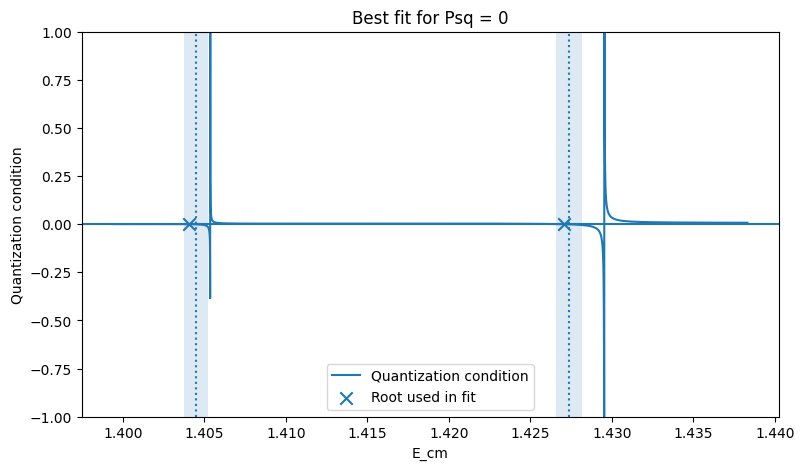

Accepted zero at E = 1.409633117
Rejected: noninteracting pole
Accepted zero at E = 1.432778227
Rejected: noninteracting pole


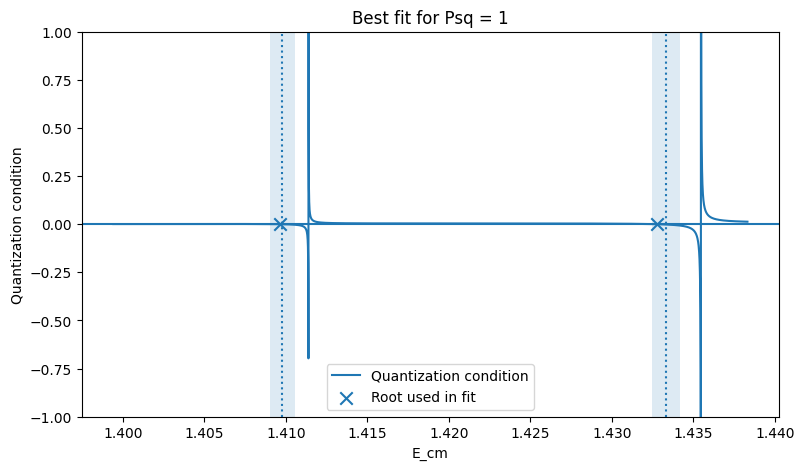

Accepted zero at E = 1.414816835
Rejected: noninteracting pole
Accepted zero at E = 1.417408273
Rejected: noninteracting pole


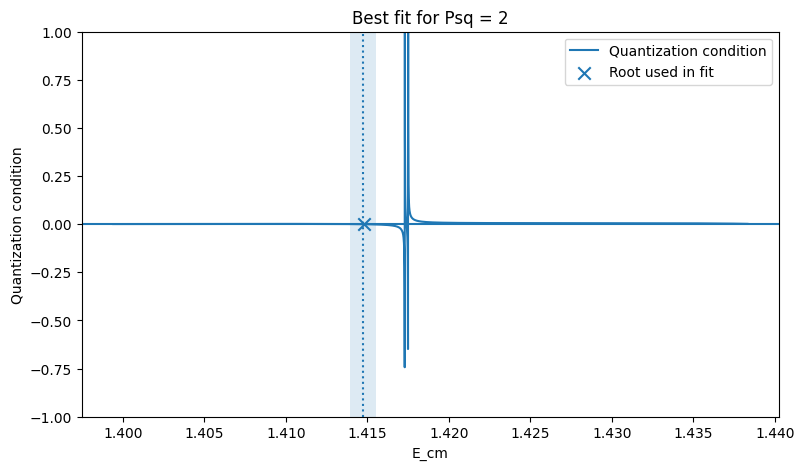

Accepted zero at E = 1.419508347
Rejected: noninteracting pole
Accepted zero at E = 1.423197937
Rejected: noninteracting pole


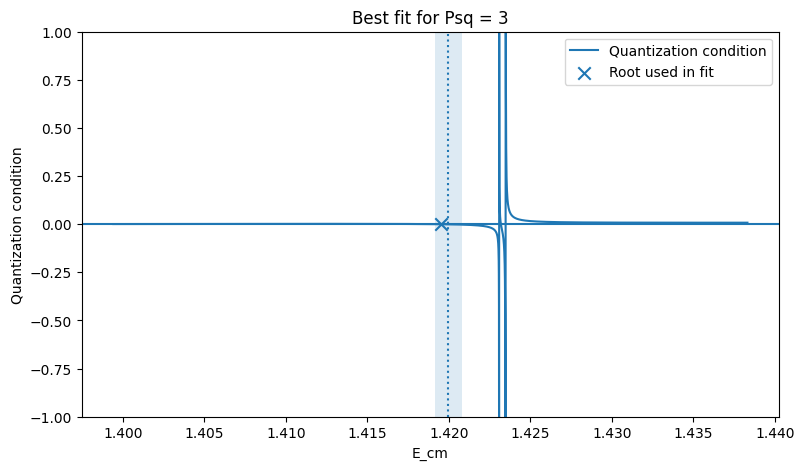

Accepted zero at E = 1.404067740
Rejected: noninteracting pole
Accepted zero at E = 1.426754660
Rejected: noninteracting pole
Accepted zero at E = 1.429085421
Rejected: noninteracting pole


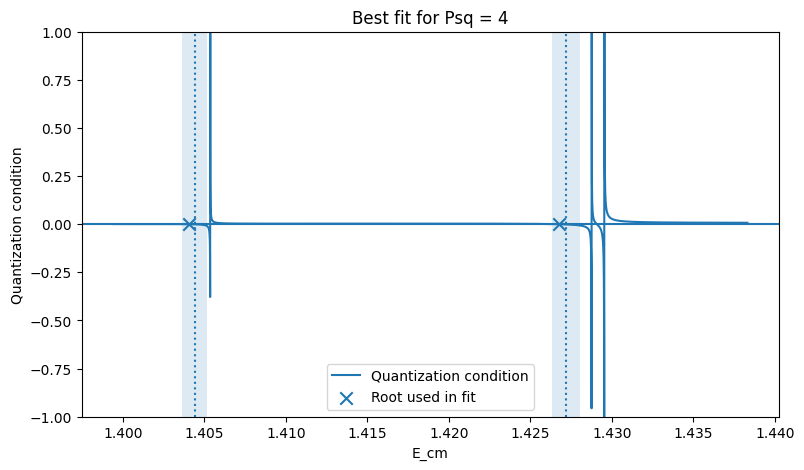

In [110]:
best_a = result.x[0]
best_r = result.x[1]


for Psq_tot in unique_Psq_tot_values:

    quantization_values = quantization_values_function(best_a, best_r, Psq_tot)

    all_zeros = find_zeros(
        quantization_values,
        min_max_energies,
        poles_by_Psq[Psq_tot]
    )

    measured_levels = actual_data[Psq_tot]

    number_expected = len(measured_levels)

    selected_zeros = select_lowest_zeros(
        all_zeros,
        number_expected
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        min_max_energies,
        quantization_values,
        label="Quantization condition"
    )
    
    plt.axhline(0)

    for measured_level in measured_levels:

        measured_energy = measured_level[0]
        measured_error = measured_level[1]

        plt.axvline(
            measured_energy,
            linestyle=":"
        )

        plt.axvspan(
            measured_energy - measured_error,
            measured_energy + measured_error,
            alpha=0.15
        )

    plt.scatter(
        selected_zeros,
        np.zeros(len(selected_zeros)),
        marker="x",
        s=80,
        label="Root used in fit"
    )

    plt.xlabel("E_cm")
    plt.ylabel("Quantization condition")
    plt.title(f"Best fit for Psq = {Psq_tot}")
    plt.ylim(-1, 1)
    plt.legend()
    plt.show()




In [94]:
#Ryan's values
a = -9.93714
r = 39.72999

for Psq_tot in unique_Psq_tot_values:

    quantization_values = quantization_values_function(
        a,
        r,
        Psq_tot
    )

    zeros = find_zeros(
        quantization_values,
        min_max_energies,
        poles_by_Psq[Psq_tot]
    )

    print(f"Psq = {Psq_tot}")
    print(zeros)
    print()

Accepted zero at E = 1.404282561
Rejected: noninteracting pole
Accepted zero at E = 1.427328375
Rejected: noninteracting pole
Psq = 0
[1.40428256 1.42732837]

Accepted zero at E = 1.409895090
Rejected: noninteracting pole
Accepted zero at E = 1.433046847
Rejected: noninteracting pole
Psq = 1
[1.40989509 1.43304685]

Accepted zero at E = 1.415153596
Rejected: noninteracting pole
Accepted zero at E = 1.417408850
Rejected: noninteracting pole
Psq = 2
[1.4151536  1.41740885]

Accepted zero at E = 1.419955499
Rejected: noninteracting pole
Accepted zero at E = 1.423199023
Rejected: noninteracting pole
Psq = 3
[1.4199555  1.42319902]

Accepted zero at E = 1.404299856
Rejected: noninteracting pole
Accepted zero at E = 1.427015399
Rejected: noninteracting pole
Accepted zero at E = 1.429093151
Rejected: noninteracting pole
Psq = 4
[1.40429986 1.4270154  1.42909315]



regenerating ryans plot

In [95]:
def Ecm_to_x(Ecm, mN):
    Ecm = np.asarray(Ecm)

    q2 = Ecm**2 / 4.0 - mN**2

    return q2 / mN**2

Accepted zero at E = 1.404282561
Rejected: noninteracting pole
Accepted zero at E = 1.427328375
Rejected: noninteracting pole
Accepted zero at E = 1.409895090
Rejected: noninteracting pole
Accepted zero at E = 1.433046847
Rejected: noninteracting pole
Accepted zero at E = 1.415153596
Rejected: noninteracting pole
Accepted zero at E = 1.417408850
Rejected: noninteracting pole
Accepted zero at E = 1.419955499
Rejected: noninteracting pole
Accepted zero at E = 1.423199023
Rejected: noninteracting pole
Accepted zero at E = 1.404299856
Rejected: noninteracting pole
Accepted zero at E = 1.427015399
Rejected: noninteracting pole
Accepted zero at E = 1.429093151
Rejected: noninteracting pole


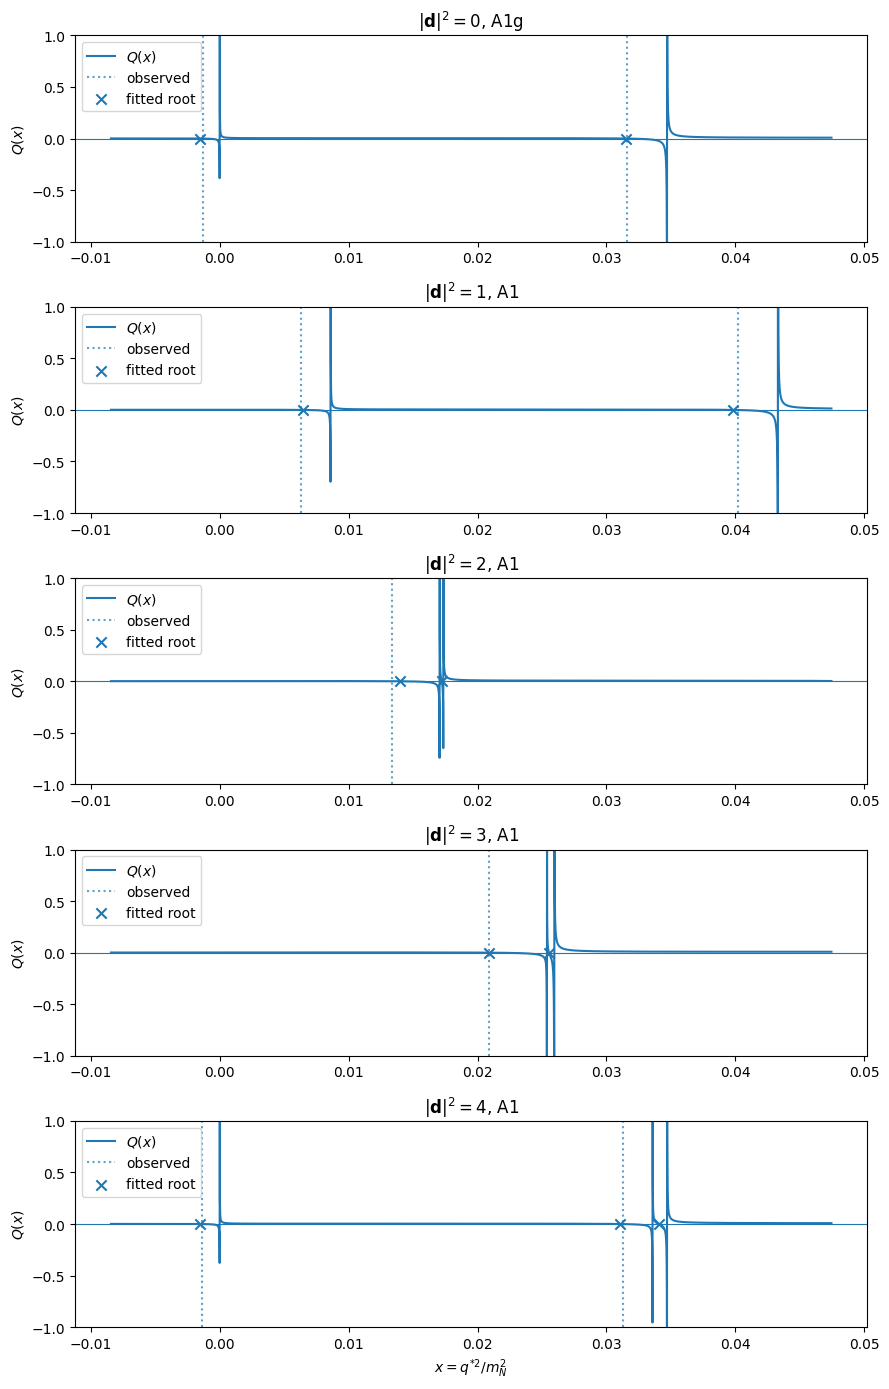

In [96]:
a_plot = -9.93714
r_plot = 39.72999

# Replace this with your actual central nucleon mass
mN_central = m

irrep_labels = {
    0: "A1g",
    1: "A1",
    2: "A1",
    3: "A1",
    4: "A1"
}

fig, axes = plt.subplots(
    len(unique_Psq_tot_values),
    1,
    figsize=(9, 14)
)

for ax, Psq_tot in zip(
    axes,
    unique_Psq_tot_values
):
    # Evaluate your quantization condition on the energy grid
    quantization_values = quantization_values_function(
        a_plot,
        r_plot,
        Psq_tot
    )

    # Find predicted energy roots
    zeros = find_zeros(
        quantization_values,
        min_max_energies,
        poles_by_Psq[Psq_tot]
    )

    # Transform horizontal coordinates from Ecm to q*²/mN²
    x_grid = Ecm_to_x(
        min_max_energies,
        mN_central
    )

    x_roots = Ecm_to_x(
        zeros,
        mN_central
    )

    # Plot Q(x)
    ax.plot(
        x_grid,
        quantization_values,
        label=r"$Q(x)$"
    )

    # Horizontal zero line
    ax.axhline(
        0,
        linewidth=0.8
    )

    # Plot observed lattice energies as vertical dotted lines
    measured_levels = actual_data[Psq_tot]

    for j, measured_level in enumerate(measured_levels):
        measured_Ecm = measured_level[0]

        measured_x = Ecm_to_x(
            measured_Ecm,
            mN_central
        )

        ax.axvline(
            measured_x,
            linestyle=":",
            alpha=0.7,
            label="observed" if j == 0 else None
        )

    # Plot every fitted root as an x at Q = 0
    ax.scatter(
        x_roots,
        np.zeros(len(x_roots)),
        marker="x",
        s=55,
        label="fitted root",
        zorder=5
    )

    ax.set_title(
        rf"$|\mathbf{{d}}|^2={Psq_tot}$, "
        rf"{irrep_labels.get(Psq_tot, 'A1')}"
    )

    ax.set_ylabel(r"$Q(x)$")

    # Zoom so divergences do not flatten the rest of the curve
    ax.set_ylim(-1.0, 1.0)

    ax.legend(loc="upper left")

axes[-1].set_xlabel(
    r"$x=q^{*2}/m_N^2$"
)

plt.tight_layout()
plt.show()

Find non interacting energy poles

In [ ]:
'''e_lab_values = []

for level in raw_levels:
    N1, N2 = level["pair"]
    E1 = np.sqrt(mN**2 + punit2 * N1)
    E2 = np.sqrt(mN**2 + punit2 * N2)
    E_lab_noninteracting = E1 + E2

    e_lab_values.append(E_lab_noninteracting[0])

print(e_lab_values)
print(len(e_lab_values))
'''

[np.float64(1.4053654041591046), np.float64(1.4295421779924136), np.float64(1.4174537910757592), np.float64(1.4414294953521958), np.float64(1.4295421779924136), np.float64(1.4410370678083857), np.float64(1.4295421779924136), np.float64(1.4525506232855672)]
8


In [ ]:
'''

poles_by_Psq = {}

for Psq in unique_Psq_tot_values:
    Ecm_for_poles = []

    for i in range(len(raw_levels)):

        if raw_levels[i]["Psq_tot"] != Psq:
            continue

        E_lab = e_lab_values[i]

        Ecm_pole = np.sqrt(E_lab**2 - punit2 * Psq)

        Ecm_for_poles.append(Ecm_pole)

    poles_by_Psq[Psq] = Ecm_for_poles
    
for Psq in unique_Psq_tot_values:
    print(Psq, poles_by_Psq[Psq])
'''


0 [np.float64(1.4053654041591046), np.float64(1.4295421779924136)]
1 [np.float64(1.411396655788882), np.float64(1.4354735316989593)]
2 [np.float64(1.41750533647436)]
3 [np.float64(1.4230894705565014)]
4 [np.float64(1.4053654041591048), np.float64(1.4287632392230982)]


In [ ]:
'''
#Find all the poles per Psq

def get_denominator(Ecm, nP, L):

    # Needed to calculate the boost
    P = twoPi * nP / L
    P_sq = np.dot(P, P)

    E = np.sqrt(Ecm**2 + P_sq)
    s = Ecm**2

    eps = 1e-16

    # Needed for qcm_sq
    qcm_value = q_cm(s + 1j * eps)
    qcm_sq = qcm_value**2

    # Needed to boost k into the CM frame
    beta = P / E

    # All allowed lattice-frame momenta
    k = (twoPi / L) * intList

    k_sq = np.sum(k**2, axis=1)

    # Needed because the Lorentz boost uses the particle energy
    omega = np.sqrt(m * m + k_sq)

    omega_cm, k_cm = lorentzBoost(omega, k, beta)

    # Needed for the denominator
    k_cm_sq = np.sum(k_cm**2, axis=1)

    denominators = qcm_sq - k_cm_sq

    return denominators


def get_all_denominators(Ecm, )
'''  